# **Normalización de espectros**
La normalización ayuda a corregir las fluctuaciones intrínsecas del proceso LIBS y a mitigar los efectos de la distancia, el enfoque y la calidad de la señal.

In [8]:
#Import libraries
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import pywt
from scipy.signal import argrelextrema
from scipy.interpolate import CubicSpline
from denoising_fun import  denoise_spectrum_uwt


#Funciones auxiliares
def leer_archivo_txt(nombre_archivo, saltar_lineas=5, delimitador=';'):
    try:
        df = pd.read_csv(nombre_archivo, delimiter=delimitador, skiprows=saltar_lineas)
        df.columns = df.columns.str.strip()
        df['Wave'] = pd.to_numeric(df['Wave'], errors='coerce')
        df['Sample'] = pd.to_numeric(df['Sample'], errors='coerce')
        df.dropna(inplace=True)

        espectro = df['Sample'].values
        wavelength = df['Wave'].values
        return espectro[16:-16], wavelength[16:-16]
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return None
    
def pad_to_multiple(x, base):
    remainder = len(x) % base
    if remainder == 0:
        return x, 0
    pad_size = base - remainder
    x_padded = np.pad(x, (0, pad_size), mode='edge')
    return x_padded, pad_size

from scipy.stats import norm
from scipy.interpolate import interp1d

def tricube_weight(x):
    """Función de peso tricúbico."""
    abs_x = np.abs(x)
    return np.where(abs_x < 1, (1 - abs_x**3)**3, 0)

def tukey_biweight(residuals, b=3.5):
    """Pesos bi-square de Tukey asimétricos."""
    weights = np.ones_like(residuals)
    mask = residuals >= 0
    weights[mask] = (1 - (residuals[mask] / b)**2)**2
    weights[residuals >= b] = 0
    return weights

def robust_baseline_estimation(spectrum, span=0.05, max_iter=50, b=3.5, tol=1e-3):
    """
    Estima la línea base de un espectro utilizando el algoritmo RBE.

    Parámetros:
    ------------
    spectrum : array_like
        Espectro 1D original (array de intensidades).
    span : float, opcional
        Proporción del total de puntos a utilizar en la regresión local. Por defecto 0.05 (5%).
    max_iter : int, opcional
        Número máximo de iteraciones para la convergencia. Por defecto 50.
    b : float, opcional
        Constante de ajuste para los pesos bi-square de Tukey. Por defecto 3.5.
    tol : float, opcional
        Tolerancia para la convergencia. Por defecto 1e-3.

    Devuelve:
    ---------
    baseline : np.ndarray
        Línea base calculada para el espectro.
    spectrum_corrected : np.ndarray
        Espectro corregido tras la eliminación de la línea base.
    """

    x = np.arange(len(spectrum))
    n = len(spectrum)
    half_window = int(np.ceil(span * n / 2))

    # Estimación inicial de la línea base usando LOWESS
    baseline = np.copy(spectrum)
    for i in range(n):
        start = max(0, i - half_window)
        end = min(n, i + half_window + 1)
        x_local = x[start:end]
        y_local = spectrum[start:end]
        weights = tricube_weight((x_local - x[i]) / half_window)
        p = np.polyfit(x_local, y_local, 1, w=weights)
        baseline[i] = np.polyval(p, x[i])

    # Iteraciones para la estimación robusta
    for iteration in range(max_iter):
        residuals = spectrum - baseline
        sigma = np.median(np.abs(residuals)) / 0.6745
        residuals_standardized = residuals / sigma
        weights_robust = tukey_biweight(residuals_standardized, b)
        baseline_new = np.copy(spectrum)
        for i in range(n):
            start = max(0, i - half_window)
            end = min(n, i + half_window + 1)
            x_local = x[start:end]
            y_local = spectrum[start:end]
            weights = tricube_weight((x_local - x[i]) / half_window) * weights_robust[start:end]
            if np.sum(weights) > 0:
                p = np.polyfit(x_local, y_local, 1, w=weights)
                baseline_new[i] = np.polyval(p, x[i])
            else:
                baseline_new[i] = baseline[i]
        # Comprobar convergencia
        if np.linalg.norm(baseline_new - baseline) < tol:
            break
        baseline = baseline_new

    

    # Corregir el espectro restando la línea base
    spectrum_corrected = spectrum - baseline
    spectrum_corrected[spectrum_corrected < 0] = 0
    return baseline, spectrum_corrected

#### Lectura de los arcivos con los espectros

In [ ]:
#Leer archivos
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '2.E2E_olivine')

UV1 = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Olivine_LIBS_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

wavelength = wavelength_UV1


#Quitamos el ruido
espectro_UV1 = denoise_spectrum_uwt(espectro_UV1)


## Normalización por suma total

Para cada espectrómetro sumamos el valor total y dividimos todos sus valores por este. Nos queda un espectro entre 0 y 1

In [5]:
def normalizar_por_suma(espectro):
    """
    Normaliza un espectro dividiendo cada valor entre la suma total del espectro.

    Parámetros:
    ------------
    espectro : array_like
        Espectro original (array 1D de intensidades).

    Devuelve:
    ---------
    espectro_normalizado : np.ndarray
        Espectro normalizado.
    """
    espectro = np.asarray(espectro)
    suma_total = np.sum(espectro)

    if suma_total == 0:
        raise ValueError("La suma del espectro es cero, no se puede normalizar.")

    espectro_normalizado = espectro / suma_total
    return espectro_normalizado


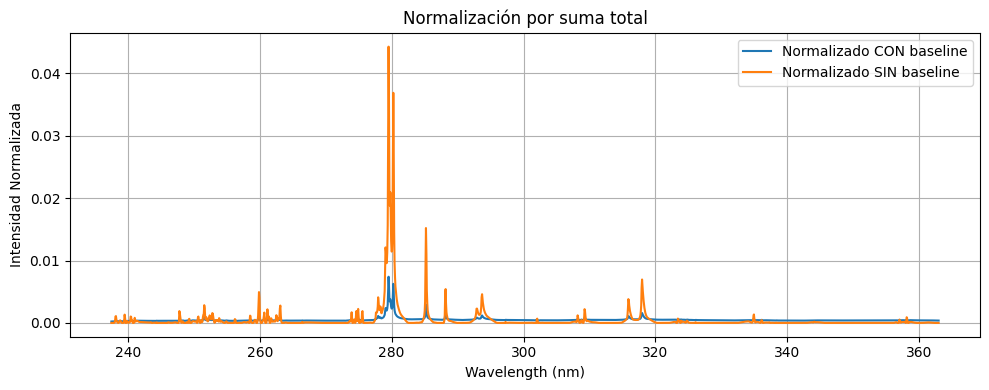

In [4]:
#nquitamos el baseline
baseline, spectrum_corrected = robust_baseline_estimation(espectro_UV1, span=0.1, max_iter=5, b=3.5)

espectro_normalizado = normalizar_por_suma(espectro_UV1)
spectrum_corrected_normalizado = normalizar_por_suma(spectrum_corrected) 

# Visualización 
plt.figure(figsize=(10, 4))
plt.plot(wavelength,espectro_normalizado, label="Normalizado CON baseline")
plt.plot(wavelength,spectrum_corrected_normalizado, label="Normalizado SIN baseline")

plt.title("Normalización por suma total")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensidad Normalizada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Normalización por contínuo

In [6]:
def normalizar_por_continuo(continuum, espectro):
    """
    Normaliza un espectro dividiendo cada valor entre la suma total del espectro.

    Parámetros:
    ------------
    espectro : array_like
        Espectro original (array 1D de intensidades).

    Devuelve:
    ---------
    espectro_normalizado : np.ndarray
        Espectro normalizado.
    """
    espectro = np.asarray(espectro)
    suma_total = np.sum(continuum)

    if suma_total == 0:
        raise ValueError("La suma del contínuo es cero, no se puede normalizar.")

    espectro_normalizado = espectro / suma_total
    return espectro_normalizado

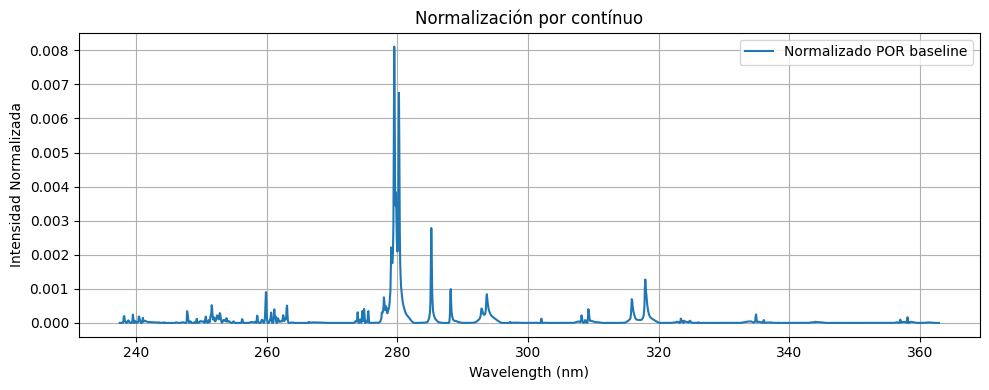

In [6]:
#nquitamos el baseline
baseline, spectrum_corrected = robust_baseline_estimation(espectro_UV1, span=0.1, max_iter=5, b=3.5)

espectro_normalizado = normalizar_por_continuo(baseline,spectrum_corrected)

# Visualización 
plt.figure(figsize=(10, 4))
plt.plot(wavelength,espectro_normalizado, label="Normalizado POR baseline")

plt.title("Normalización por contínuo")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensidad Normalizada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparación Visual

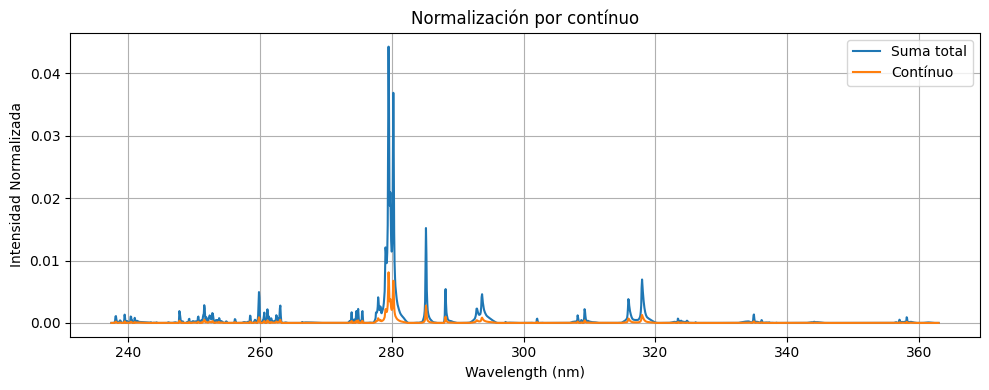

In [7]:
#nquitamos el baseline
baseline, spectrum_corrected = robust_baseline_estimation(espectro_UV1, span=0.1, max_iter=5, b=3.5)

espectro_normalizado_suma = normalizar_por_suma(spectrum_corrected) 
espectro_normalizado_continuo = normalizar_por_continuo(baseline,spectrum_corrected)

# Visualización
plt.figure(figsize=(10, 4))
plt.plot(wavelength,espectro_normalizado_suma, label="Suma total")
plt.plot(wavelength,espectro_normalizado_continuo, label="Contínuo")

plt.title("Normalización por contínuo")
plt.xlabel("Wavelength (nm)")
plt.ylabel("Intensidad Normalizada")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Comparación con datos de Sulfatos

In [9]:
# Ruta relativa desde Pre_Processing a los espectros
ruta_espectros = os.path.join('..', 'Spectra', '20250321_First_test')

UV1 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324767SP.txt')
UV2 = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324768SP.txt')
VIS = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324769SP.txt')
NIR = os.path.join(ruta_espectros, 'Sulfato50_shot01_7324770SP.txt')

espectro_UV1, wavelength_UV1 = leer_archivo_txt(UV1)
espectro_UV2, wavelength_UV2 = leer_archivo_txt(UV2)
espectro_VIS, wavelength_VIS = leer_archivo_txt(VIS)
espectro_NIR, wavelength_NIR  = leer_archivo_txt(NIR)

espectro_UV1 = denoise_spectrum_uwt(espectro_UV1)
espectro_UV2 = denoise_spectrum_uwt(espectro_UV2)
espectro_VIS = denoise_spectrum_uwt(espectro_VIS)
espectro_NIR = denoise_spectrum_uwt(espectro_NIR)

C:\Users\Nacho\AppData\Local\Temp\ipykernel_24244\3815016435.py:106: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_local, y_local, 1, w=weights)
C:\Users\Nacho\AppData\Local\Temp\ipykernel_24244\3815016435.py:106: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_local, y_local, 1, w=weights)
C:\Users\Nacho\AppData\Local\Temp\ipykernel_24244\3815016435.py:106: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_local, y_local, 1, w=weights)
C:\Users\Nacho\AppData\Local\Temp\ipykernel_24244\3815016435.py:106: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_local, y_local, 1, w=weights)
C:\Users\Nacho\AppData\Local\Temp\ipykernel_24244\3815016435.py:106: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_local, y_local, 1, w=weights)
C:\Users\Nacho\AppData\Local\Temp\ipykernel_24244\3815016435.py:106: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_local, y_local, 1, w=weights)
C:\Users\N

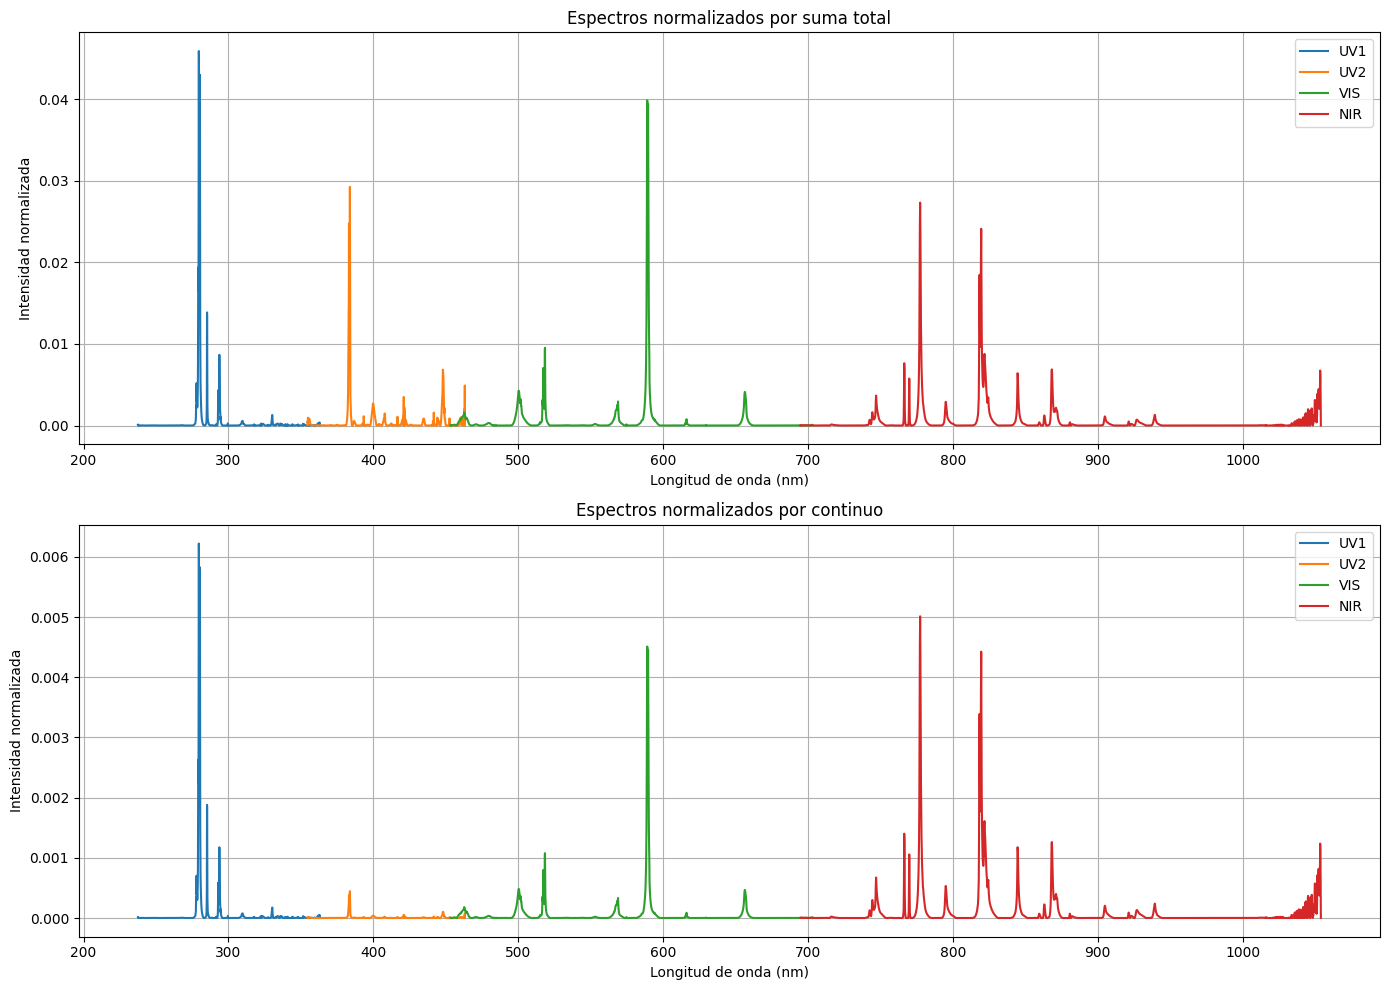

In [ ]:
# Función para normalizar por suma
def normalizar_por_suma(espectro):
    suma_total = np.sum(espectro)
    if suma_total == 0:
        return espectro
    return espectro / suma_total


# Aplicar baseline removal (RBE)
continuum_UV1, espectro_UV1_baseless = robust_baseline_estimation(espectro_UV1)
continuum_UV2, espectro_UV2_baseless = robust_baseline_estimation(espectro_UV2)
continuum_VIS, espectro_VIS_baseless = robust_baseline_estimation(espectro_VIS)
continuum_NIR, espectro_NIR_baseless = robust_baseline_estimation(espectro_NIR)

# Nombres y organización
nombres = ['UV1', 'UV2', 'VIS', 'NIR']
espectros_baseless = [espectro_UV1_baseless, espectro_UV2_baseless, espectro_VIS_baseless, espectro_NIR_baseless]
wavelengths = [wavelength_UV1, wavelength_UV2, wavelength_VIS, wavelength_NIR]
continuum = [continuum_UV1, continuum_UV2, continuum_VIS, continuum_NIR]

# Normalización por suma y por continuo (usando zip correctamente)
norm_suma = [normalizar_por_suma(e) for e in espectros_baseless]
norm_continuo = [normalizar_por_continuo(w, e) for w, e in zip(continuum, espectros_baseless)]

# Visualización
fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

# Gráfica 1: Normalización por suma
for i in range(4):
    axs[0].plot(wavelengths[i], norm_suma[i], label=f'{nombres[i]}')
axs[0].set_title("Espectros normalizados por suma total")
axs[0].set_xlabel("Longitud de onda (nm)")
axs[0].set_ylabel("Intensidad normalizada")
axs[0].legend()
axs[0].grid(True)

# Gráfica 2: Normalización por continuo
for i in range(4):
    axs[1].plot(wavelengths[i], norm_continuo[i], label=f'{nombres[i]}')
axs[1].set_title("Espectros normalizados por continuo")
axs[1].set_xlabel("Longitud de onda (nm)")
axs[1].set_ylabel("Intensidad normalizada")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()


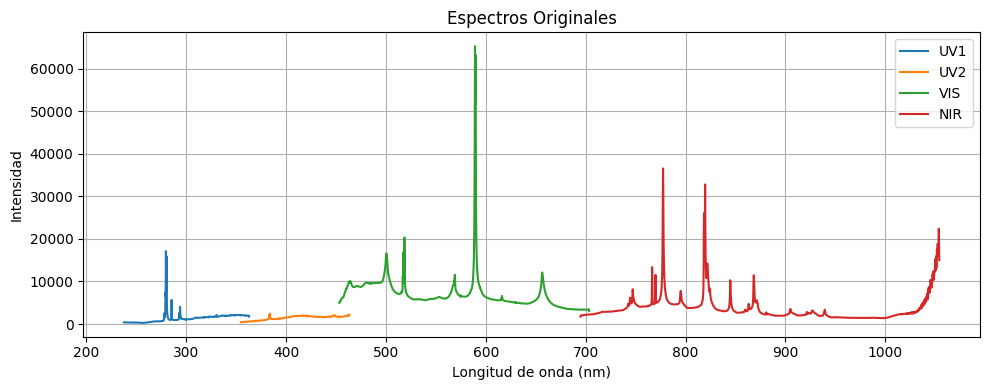

In [14]:
espectros = [espectro_UV1, espectro_UV2, espectro_VIS, espectro_NIR]

# Visualización
plt.figure(figsize=(10, 4))

# Gráfica 1: Normalización por suma
for i in range(4):
    plt.plot(wavelengths[i], espectros[i], label=f'{nombres[i]}')
plt.title("Espectros Originales")
plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Intensidad")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()